#### Note that in this version of OptScale 1, we no longer use MuSigmaPredictor for MLE starting point. Instead, we set Mu = 0.8 and Sigma = 0.2 for all datasets, making this a simplified but still effective OptScale.

In [1]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import root
from scipy.optimize import minimize
from tqdm import tqdm
import os 

from utils import *

# Set random seed for reproducibility (same as in train_predictor_initial.py)
torch.manual_seed(42)
np.random.seed(42)


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATASET = 'MATH500'

Using device: cuda:0


In [2]:
model_name = "../models/DeepSeek-R1-Distill-Qwen-1.5B"  #加载预测器来估算每道题目的“得分分布参数”（均值 和 方差）
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token

def load_validation_data(batch_size=16):
    # 加载 AIME 2024 竞赛的原始题目和答案
    with open('../data/test_prompts/math500_test.json', 'r') as f:         
        dataset = json.load(f)

    # 加载之前已经生成好的模型回复（completions）以及它们的打分数据    
    with open('../data/completions/llama8b/parallel/scored_math500_llama8b_Useq.json', 'r') as f:
        completion_data = json.load(f)

    # 从 JSON 数据中提取出具体的字段，转换成列表
    texts = [item['problem'] for item in dataset]          # 原始题目文本
    gt_answers = [item['answer'] for item in dataset]      # 标准答案
    completions = [item['score']['completions'] for item in completion_data]                     # 模型生成的多个回答
    completion_tokens = [item['score']['completion_tokens'] for item in completion_data]         # 生成回答所用的 token 数量
    scores = [item['score']['scores'] for item in completion_data]                               # 对应的评分（通常是奖励模型打的分）
    # =========================================================
    # 【新增】将之前辛苦算出来的 u_seqs 从 JSON 中提取出来
    useqs = [item['score']['u_seqs'] for item in completion_data]
    # =========================================================
    
    # 将提取出的数据赋值给验证集变量
    val_texts = texts
    val_gt_answers = gt_answers
    val_completions = completions
    val_completion_tokens = completion_tokens
    val_scores = scores
    val_useqs = useqs

    print(f"Total dataset size: {len(texts)}")
    print(f"Validation size: {len(val_texts)}")

    # 检查本地是否已经存在缓存的 mu/sigma 文件
    if os.path.exists(f'{DATASET}_train_mu_sigma.json'):
        print("Loading existing mu/sigma parameters...")
        with open(f'{DATASET}_train_mu_sigma.json', 'r') as f:
            val_labels = json.load(f)
    else:
        # 如果没有缓存，则需要动用模型进行推理预测
        print("Predicting mu/sigma parameters using QwenMuSigmaPredictor...")

        torch.cuda.empty_cache()  # 清理 GPU 显存防止 OOM

        # 实例化预测器模型，并将它搬到 GPU 上
        model = QwenMuSigmaPredictor(model_name).to(device)
        # 定义预训练权重（checkpoint）的路径
        checkpoint_path = '../train_predictor/checkpoints_direct_qwen_real/best_predictor_model_direct_qwen_real.pt'
        # 加载权重文件。先加载到 CPU 是为了安全，随后通过 load_state_dict 注入到模型中
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint)

        # 创建一个不包含标签的验证数据集对象（仅包含输入文本）
        val_dataset = TextDatasetNoLabels(val_texts, tokenizer)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        val_labels = []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                # 模型前向传播，得到输出（这里输出的通常是预测的 mu 和 sigma）
                outputs = model(input_ids, attention_mask)
                # 将推理结果从 GPU 搬回 CPU，转换为 Python 列表并存入总表
                val_labels.extend(outputs.cpu().numpy().tolist())

        # 将所有题目预测出的 mu 和 sigma 保存到本地 JSON，避免下次重复计算
        with open(f'{DATASET}_train_mu_sigma.json', 'w') as f:
            json.dump(val_labels, f)

    val_dataset = TextDataset(val_texts, val_labels, tokenizer)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
   # 【修改】在返回值里，加上我们的 val_useqs
    return val_loader, val_texts, val_gt_answers, val_completions, val_completion_tokens, val_scores, val_labels, val_useqs, tokenizer

# 【修改】执行加载，注意等号左边多接收了一个 val_useqs
val_loader, val_texts, val_gt_answers, val_completions, val_completion_tokens, val_scores, val_labels, val_useqs, tokenizer = load_validation_data()

Total dataset size: 500
Validation size: 500
Loading existing mu/sigma parameters...


In [3]:
import math
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


# =====================================================================
# 【修改】定义带权重的截断正态分布 MAP 目标函数 
# 在截断逻辑的基础上加入权重
# =====================================================================
def neg_log_posterior_weighted(params, data_array, weights, prior_mu, prior_sigma, prior_mu_std=0.1, prior_sigma_std=0.1):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
        
    # Log likelihood (Truncated Normal Logic)
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    if Z <= 0:
        return np.inf

    # 计算每个样本的未加权对数似然 (不包含 Z)
    per_sample_log_lik = norm.logpdf((data_array - mu)/sigma) - np.log(sigma)
    
    # 加权求和：让高质量样本主导拟合
    weighted_sum = np.sum(weights * per_sample_log_lik)
    
    # 归一化项惩罚
    # 这里的逻辑是：权重之和代表了“有效样本量”，用来缩放截断带来的惩罚
    effective_n = np.sum(weights) 
    if effective_n == 0: effective_n = 1e-6 # 防止全为0权重导致的问题
    
    log_likelihood = weighted_sum - effective_n * np.log(Z)
    
    # Log prior
    log_prior_mu = norm.logpdf(mu, loc=prior_mu, scale=prior_mu_std)
    log_prior_sigma = norm.logpdf(sigma, loc=prior_sigma, scale=prior_sigma_std)
    
    return -(log_likelihood + log_prior_mu + log_prior_sigma)


# 1. 算上帝视角 GT 参数 (保持原样)
original_params_compare = []
for idx, score in enumerate(val_scores):
    data = np.array(score[0][:100])
    initial_mu = np.mean(data)
    initial_sigma = np.std(data)
    result = minimize(lambda params: neg_log_likelihood(params, data), 
                     [initial_mu, initial_sigma],
                     bounds=[(None, None), (1e-6, None)], 
                     method='L-BFGS-B')
    mu_hat, sigma_hat = result.x
    original_params_compare.append((mu_hat, sigma_hat))

# 2. 准备储存三组实验数据的列表
mle_estimated_params = []          # [基线 1] OptScale-MLE 
vanilla_map_estimated_params = []  # [基线 2] OptScale-MAP (截断版)
useq_map_estimated_params = []     # [我们] Useq-MAP (带测谎仪+截断)
predictor_params = []              # 1.5B 预测先验

# 3. 完美对齐的表头打印
print("\nComparison of Estimation Methods (first 50 examples):")
header = (f"{'ID':<5} | {'Prior_μ':>10} {'Prior_σ':>10} | "
          f"{'MLE_μ':>10} {'MLE_σ':>10} | "
          f"{'Opt_MAP_μ':>12} {'Opt_MAP_σ':>12} | "
          f"{'Useq_MAP_μ':>12} {'Useq_MAP_σ':>12} | "
          f"{'GT_μ':>10} {'GT_σ':>10}")
print(header)
print("-" * len(header))

peek_number = 3
WINDOW_SIZE = 15 

for i, (score, prediction, useq) in enumerate(zip(val_scores, val_labels, val_useqs)):
    peek_data = np.array(score[0][:peek_number])
    peek_useqs = np.array(useq[0][:peek_number])
    
    # 储存先验
    prior_mu, prior_sigma = prediction
    predictor_params.append((prior_mu, prior_sigma))
    
    # ----------------------------------------------------
    # [推断 1] 计算 MLE
    initial_mu, initial_sigma = np.mean(peek_data), np.std(peek_data)
    mle_result = minimize(
        lambda params: neg_log_likelihood(params, peek_data),
        [initial_mu, initial_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    mle_mu, mle_sigma = mle_result.x
    mle_estimated_params.append((mle_mu, mle_sigma))
    
    # ----------------------------------------------------
    # [推断 2] 计算 OptScale-MAP (Vanilla MAP - 截断版)
    # 注意：这里不需要传 weights
    vanilla_map_result = minimize(
        lambda params: neg_log_posterior(
            params, peek_data, prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    opt_map_mu, opt_map_sigma = vanilla_map_result.x
    vanilla_map_estimated_params.append((opt_map_mu, opt_map_sigma))
    
    # ----------------------------------------------------
    # [推断 3] 计算 Useq-MAP (我们的方法 - 截断+加权)
    weights = []
    for u in peek_useqs:
        if u > 900: 
            weights.append(0.0)
        else: 
            weights.append(1.0 / math.exp(u / WINDOW_SIZE))
            
    useq_map_result = minimize(
        lambda params: neg_log_posterior_weighted(
            params, peek_data, weights=np.array(weights), prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    useq_map_mu, useq_map_sigma = useq_map_result.x
    useq_map_estimated_params.append((useq_map_mu, useq_map_sigma))
    
    # ----------------------------------------------------
    # 打印对比
    if i < 50:
        gt_mu, gt_sigma = original_params_compare[i]
        print(f"{i:<5} | {prior_mu:10.4f} {prior_sigma:10.4f} | "
            f"{mle_mu:10.4f} {mle_sigma:10.4f} | "
            f"{opt_map_mu:12.4f} {opt_map_sigma:12.4f} | "
            f"{useq_map_mu:12.4f} {useq_map_sigma:12.4f} | "
            f"{gt_mu:10.4f} {gt_sigma:10.4f}")

# 评估性能
analyze_estimation_performance(predictor_params, mle_estimated_params, useq_map_estimated_params, original_params_compare)

/home/luorongchuan/.local/lib/python3.10/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0



Comparison of Estimation Methods (first 50 examples):
ID    |    Prior_μ    Prior_σ |      MLE_μ      MLE_σ |    Opt_MAP_μ    Opt_MAP_σ |   Useq_MAP_μ   Useq_MAP_σ |       GT_μ       GT_σ
-------------------------------------------------------------------------------------------------------------------------------------
0     |     0.9538     0.0798 |     0.8493     0.0620 |       0.8654       0.0677 |       0.9221       0.0984 |     0.8583     0.1831
1     |     0.8792     0.0529 |    52.9192     1.7991 |       0.9676       0.0937 |       0.9459       0.0798 |    64.8574     2.6690
2     |     0.8755     0.1231 |     0.7767     0.0926 |       0.8106       0.1092 |       0.8493       0.1335 |     0.7683     0.1627
3     |     0.9809     0.0482 |    43.0076     1.8463 |       0.9998       0.1108 |       0.9870       0.0996 |   106.7850     2.8311
4     |     0.9098     0.0816 |    99.8436     3.7728 |       0.9342       0.1781 |       0.9352       0.1480 |    88.1711     3.7865
5     |

In [4]:
# Load baseline results
with open(f'{DATASET}_BoN_results.json', 'r') as f:
    data = json.load(f)

# Reconstruct the baseline arrays
baseline_accuracy_values = []
baseline_average_token_counts = []

for item in data:
    baseline_accuracy_values.append(item['accuracy'])
    baseline_average_token_counts.append(item['token_count'])

Target Score Panel: [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
Percentile Panel: [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
Max N: 8

[1/3] Evaluating Baseline 1 (OptScale-MLE)...
🚀 启动多核并行评测: MLE


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 8469.06it/s]



[2/3] Evaluating Baseline 2 (OptScale-MAP)...
🚀 启动多核并行评测: Vanilla MAP


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 24134.09it/s]



[3/3] Evaluating Ours (Useq-MAP + WRF)...
🚀 启动多核并行评测: Useq-MAP+WRF


...


[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...
🚀 启动多核并行评测: Useq-MAP + BoN


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 15471.19it/s]



[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...
🚀 启动多核并行评测: Vanilla MAP + WRF


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 25413.61it/s]



[INFO] 正在提取并打印帕累托最优配置...

------------------------------------------------------------
🌟 OptScale-MLE Pareto-optimal configurations:
------------------------------------------------------------
Target Score: 0.7   | Percentile: 0.1   | Accuracy: 0.6020 | Avg Token Count: 6064.49
Target Score: 0.7   | Percentile: 0.075 | Accuracy: 0.6040 | Avg Token Count: 6273.00
Target Score: 0.7   | Percentile: 0.035 | Accuracy: 0.6060 | Avg Token Count: 6587.57
Target Score: 0.75  | Percentile: 0.1   | Accuracy: 0.6080 | Avg Token Count: 6623.27
Target Score: 0.8   | Percentile: 0.1   | Accuracy: 0.6100 | Avg Token Count: 7341.00
Target Score: 0.8   | Percentile: 0.05  | Accuracy: 0.6120 | Avg Token Count: 7614.87
Target Score: 0.8   | Percentile: 0.035 | Accuracy: 0.6140 | Avg Token Count: 7717.09
Target Score: 0.8   | Percentile: 0.02  | Accuracy: 0.6180 | Avg Token Count: 7849.96
Target Score: 0.8   | Percentile: 0.01  | Accuracy: 0.6200 | Avg Token Count: 7966.97
Target Score: 0.85  | Percentil

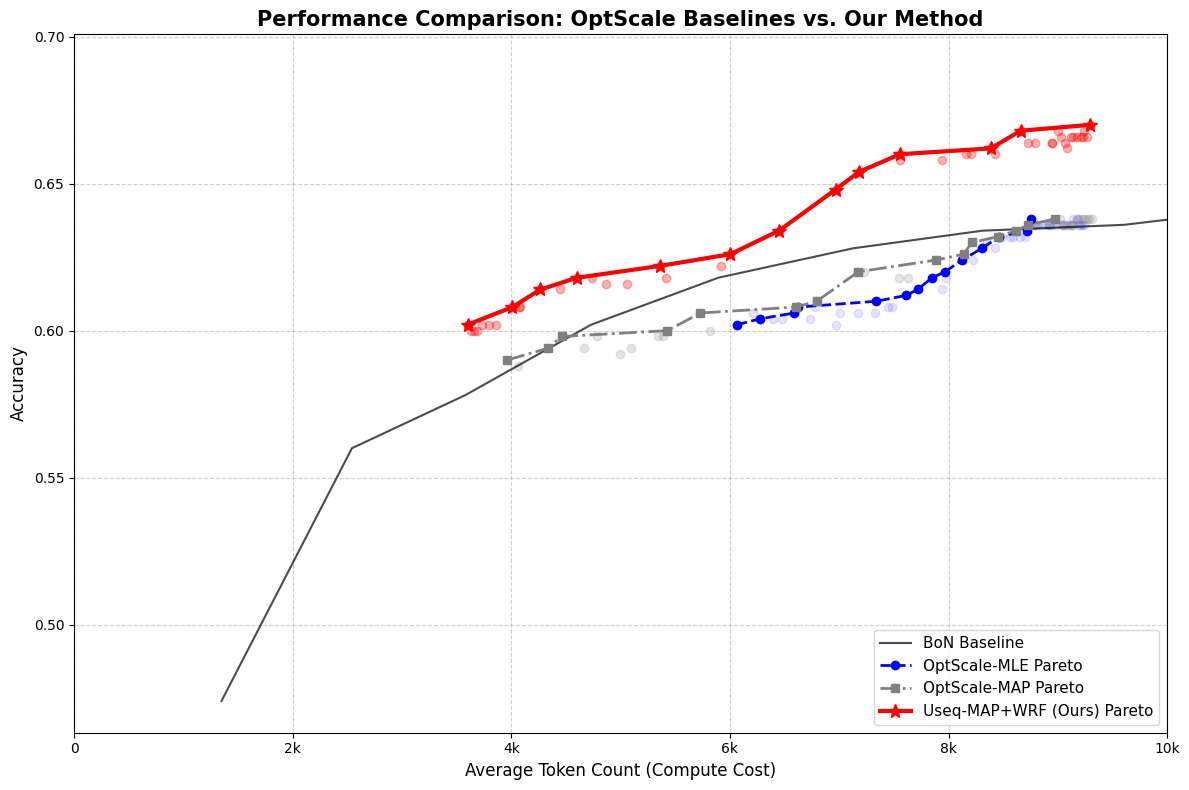

In [5]:
import math
import numpy as np
import json
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 0. 参数设置 (解锁大算力上限 N=8)
# ==========================================
target_score_panel_values = [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
percentile_panel_values = [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
max_N_panel = 8  # 调大上限，给 WRF 足够的样本进行多数投票
WINDOW_SIZE = 15

print("Target Score Panel:", target_score_panel_values)
print("Percentile Panel:", percentile_panel_values)
print(f"Max N: {max_N_panel}")

# ==========================================
# 1. 定义核心函数 (WRF投票 & 通用评测器)
# ==========================================
def get_wrf_best_answer(completions, scores, alpha=0.85): 
    if not scores: 
        return None
    
    ans_stats = {}
    for comp, score in zip(completions, scores):
        ans = get_answer(comp)
        if ans is not None and ans != "":
            if ans not in ans_stats:
                # 严格按照 WRF 逻辑，恢复平均分统计
                ans_stats[ans] = {'count': 0, 'total_score': 0.0}
            
            ans_stats[ans]['count'] += 1
            ans_stats[ans]['total_score'] += score

    if not ans_stats:
        highest_idx = scores.index(max(scores))
        return get_answer(completions[highest_idx])
        
    unique_answers = list(ans_stats.keys())
    
    if len(unique_answers) == 1:
        return unique_answers[0] 

    # 计算平均分并进行归一化
    R_dict = {ans: stats['total_score'] / stats['count'] for ans, stats in ans_stats.items()}
    F_dict = {ans: stats['count'] for ans, stats in ans_stats.items()}

    R_values = list(R_dict.values())
    F_values = list(F_dict.values())
    
    R_min, R_max = min(R_values), max(R_values)
    F_min, F_max = min(F_values), max(F_values)

    best_ans = None
    max_wrf_score = -float('inf')

    for ans in unique_answers:
        if R_max > R_min:
            norm_R = (R_dict[ans] - R_min) / (R_max - R_min)
        else:
            norm_R = 1.0  

        if F_max > F_min:
            norm_F = (F_dict[ans] - F_min) / (F_max - F_min)
        else:
            norm_F = 1.0  

        wrf_score = alpha * norm_R + (1.0 - alpha) * norm_F

        if wrf_score > max_wrf_score:
            max_wrf_score = wrf_score
            best_ans = ans

    return best_ans

from joblib import Parallel, delayed

def evaluate_method(params_list, use_wrf=False, desc=""):
    """多核并行加速版的评测器"""
    
    # 1. 扁平化网格搜索参数，共 8 * 6 = 48 组配置
    grid_configs = [(ts, p) for ts in target_score_panel_values for p in percentile_panel_values]
    
    # 2. 剥离出：单次配置的完整评测逻辑
    def eval_single_config(target_score, percentile):
        min_N_required = []
        # 计算每一题在这个阈值下需要的最小 N
        for mu, sigma in params_list:
            min_N = find_min_N_for_threshold(mu, sigma, target_score=target_score, 
                                             percentile=percentile, max_N=max_N_panel)
            if min_N < peek_number:
                min_N = peek_number
            min_N_required.append(min_N)
            
        correct = 0
        entire_token_count = 0

        # 遍历数据集
        for idx, item in enumerate(val_texts):
            N = min_N_required[idx]
            completions = val_completions[idx][0][:N]
            scores = val_scores[idx][0][:N]
            completion_tokens = val_completion_tokens[idx][0][:N]
            entire_token_count += sum(completion_tokens)

            if use_wrf:
                current_alpha = 0.75 
                final_answer = get_wrf_best_answer(completions, scores, alpha=current_alpha)
            else:
                highest_idx = scores.index(max(scores))
                while completions[highest_idx] == "":
                    scores[highest_idx] = 0 
                    if max(scores) == 0: break
                    highest_idx = scores.index(max(scores))
                final_answer = get_answer(completions[highest_idx])

            if verify_extracted_answer(val_gt_answers[idx], final_answer):
                correct += 1

        return {
            'target_score': target_score, 'percentile': percentile,
            'accuracy': correct / len(val_texts),
            'average_token_count': entire_token_count / len(val_texts)
        }

    # 3. 启动多核并行计算 (n_jobs=-1 表示火力全开，使用所有可用 CPU 核心)
    print(f"🚀 启动多核并行评测: {desc}")
    results = Parallel(n_jobs=-1)(
        delayed(eval_single_config)(ts, p) 
        for ts, p in tqdm(grid_configs, desc=f"Grid Searching")
    )
    
    return results
# ==========================================
# 2. 依次跑三个方法的评测 (三国杀)
# ==========================================
print("\n[1/3] Evaluating Baseline 1 (OptScale-MLE)...")
mle_results = evaluate_method(mle_estimated_params, use_wrf=False, desc="MLE")

print("\n[2/3] Evaluating Baseline 2 (OptScale-MAP)...")
vanilla_map_results = evaluate_method(vanilla_map_estimated_params, use_wrf=False, desc="Vanilla MAP")

print("\n[3/3] Evaluating Ours (Useq-MAP + WRF)...")
useq_map_results = evaluate_method(useq_map_estimated_params, use_wrf=True, desc="Useq-MAP+WRF")

# ---------------------------------------------------------
# 新增的诊断测试：控制变量法 (Ablation Study)
# ---------------------------------------------------------
print("\n[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...")
# 目的：看是不是 Useq-MAP 算出来的算力分配 N 有问题
useq_bon_results = evaluate_method(useq_map_estimated_params, use_wrf=False, desc="Useq-MAP + BoN")

print("\n[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...")
# 目的：看是不是 WRF 投票机制在 GSM8K 上水土不服
vanilla_wrf_results = evaluate_method(vanilla_map_estimated_params, use_wrf=True, desc="Vanilla MAP + WRF")




# (可选) 将我们的最好结果存下来
with open(f'{DATASET}_Useq_MAP_WRF_results_{max_N_panel}.json', 'w') as f:
    json.dump(useq_map_results, f)

# ==========================================
# 3. 终极数据提取与画图
# ==========================================
print("\n[INFO] 正在提取并打印帕累托最优配置...")

def get_pareto_frontier(results):
    """提取帕累托前沿点，并保留其所有配置参数"""
    # 按 Token 消耗从小到大排序
    sorted_results = sorted(results, key=lambda x: x['average_token_count'])
    pareto_front = []
    max_acc = -1
    for res in sorted_results:
        # 帕累托核心逻辑：只有当准确率严格大于之前的最大值时，才将其加入前沿
        if res['accuracy'] > max_acc:
            pareto_front.append(res)
            max_acc = res['accuracy']
    return pareto_front

def print_pareto_config(name, pareto_front):
    """精美打印配置表"""
    print(f"\n{'-'*60}")
    print(f"🌟 {name} Pareto-optimal configurations:")
    print(f"{'-'*60}")
    for res in pareto_front:
        print(f"Target Score: {res['target_score']:<5} | Percentile: {res['percentile']:<5} | "
              f"Accuracy: {res['accuracy']:.4f} | Avg Token Count: {res['average_token_count']:.2f}")

# 1. 提取三条前沿数据
mle_pareto = get_pareto_frontier(mle_results)
vanilla_map_pareto = get_pareto_frontier(vanilla_map_results)
useq_map_pareto = get_pareto_frontier(useq_map_results)

useq_bon_results = get_pareto_frontier(useq_bon_results)
vanilla_wrf_results = get_pareto_frontier(vanilla_wrf_results)


# 2. 打印到终端 (直接可以复制进论文的表格里)

print_pareto_config("OptScale-MLE", mle_pareto)
print_pareto_config("OptScale-MAP (Vanilla)", vanilla_map_pareto)
print_pareto_config("Useq-MAP+WRF (Ours)", useq_map_pareto)
print_pareto_config("只测 Useq-MAP 参数，不用 WRF (用原版最高分)", useq_bon_results)
print_pareto_config("用原版的 Vanilla MAP 参数，加上 WRF", vanilla_wrf_results)

# 3. 画图环节
plt.figure(figsize=(12, 8))

# 画原版 Best-of-N 基线 (黑线)
if 'baseline_accuracy_values' in locals() and baseline_accuracy_values:
    plt.plot(baseline_average_token_counts, baseline_accuracy_values, 'k-', label='BoN Baseline', alpha=0.7)

# 分离出 x(Token) 和 y(Accuracy) 用于画线
mle_x = [r['average_token_count'] for r in mle_pareto]
mle_y = [r['accuracy'] for r in mle_pareto]

vanilla_x = [r['average_token_count'] for r in vanilla_map_pareto]
vanilla_y = [r['accuracy'] for r in vanilla_map_pareto]

useq_x = [r['average_token_count'] for r in useq_map_pareto]
useq_y = [r['accuracy'] for r in useq_map_pareto]

# 1. 蓝线：MLE
plt.scatter([r['average_token_count'] for r in mle_results], [r['accuracy'] for r in mle_results], c='blue', alpha=0.1)
plt.plot(mle_x, mle_y, 'b--', linewidth=2, marker='o', label='OptScale-MLE Pareto')

# 2. 灰线：Vanilla MAP
plt.scatter([r['average_token_count'] for r in vanilla_map_results], [r['accuracy'] for r in vanilla_map_results], c='gray', alpha=0.2)
plt.plot(vanilla_x, vanilla_y, color='gray', linestyle='-.', linewidth=2, marker='s', label='OptScale-MAP Pareto')

# 3. 红线：Ours (Useq-MAP + WRF)
plt.scatter([r['average_token_count'] for r in useq_map_results], [r['accuracy'] for r in useq_map_results], c='red', alpha=0.3)
plt.plot(useq_x, useq_y, 'r-', linewidth=3, marker='*', markersize=10, label='Useq-MAP+WRF (Ours) Pareto')

# 格式化 X 轴，让它显示 10k, 20k 这种紧凑格式，看起来更高级
def format_func(value, tick_number):
    return f'{int(value/1000)}k' if value >= 1000 else int(value)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# 图表美化
plt.title('Performance Comparison: OptScale Baselines vs. Our Method', fontsize=15, fontweight='bold')
plt.xlabel('Average Token Count (Compute Cost)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
# 【新增这行代码】限制 X 轴范围从 0 到 100,000
plt.xlim(0, 10000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
import math
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


# =====================================================================
# 【修改】定义带权重的截断正态分布 MAP 目标函数 
# 在截断逻辑的基础上加入权重
# =====================================================================
def neg_log_posterior_weighted(params, data_array, weights, prior_mu, prior_sigma, prior_mu_std=0.1, prior_sigma_std=0.1):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
        
    # Log likelihood (Truncated Normal Logic)
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    if Z <= 0:
        return np.inf

    # 计算每个样本的未加权对数似然 (不包含 Z)
    per_sample_log_lik = norm.logpdf((data_array - mu)/sigma) - np.log(sigma)
    
    # 加权求和：让高质量样本主导拟合
    weighted_sum = np.sum(weights * per_sample_log_lik)
    
    # 归一化项惩罚
    # 这里的逻辑是：权重之和代表了“有效样本量”，用来缩放截断带来的惩罚
    effective_n = np.sum(weights) 
    if effective_n == 0: effective_n = 1e-6 # 防止全为0权重导致的问题
    
    log_likelihood = weighted_sum - effective_n * np.log(Z)
    
    # Log prior
    log_prior_mu = norm.logpdf(mu, loc=prior_mu, scale=prior_mu_std)
    log_prior_sigma = norm.logpdf(sigma, loc=prior_sigma, scale=prior_sigma_std)
    
    return -(log_likelihood + log_prior_mu + log_prior_sigma)


# 1. 算上帝视角 GT 参数 (保持原样)
original_params_compare = []
for idx, score in enumerate(val_scores):
    data = np.array(score[0][:100])
    initial_mu = np.mean(data)
    initial_sigma = np.std(data)
    result = minimize(lambda params: neg_log_likelihood(params, data), 
                     [initial_mu, initial_sigma],
                     bounds=[(None, None), (1e-6, None)], 
                     method='L-BFGS-B')
    mu_hat, sigma_hat = result.x
    original_params_compare.append((mu_hat, sigma_hat))

# 2. 准备储存三组实验数据的列表
mle_estimated_params = []          # [基线 1] OptScale-MLE 
vanilla_map_estimated_params = []  # [基线 2] OptScale-MAP (截断版)
useq_map_estimated_params = []     # [我们] Useq-MAP (带测谎仪+截断)
predictor_params = []              # 1.5B 预测先验

# 3. 完美对齐的表头打印
print("\nComparison of Estimation Methods (first 50 examples):")
header = (f"{'ID':<5} | {'Prior_μ':>10} {'Prior_σ':>10} | "
          f"{'MLE_μ':>10} {'MLE_σ':>10} | "
          f"{'Opt_MAP_μ':>12} {'Opt_MAP_σ':>12} | "
          f"{'Useq_MAP_μ':>12} {'Useq_MAP_σ':>12} | "
          f"{'GT_μ':>10} {'GT_σ':>10}")
print(header)
print("-" * len(header))

peek_number = 5
WINDOW_SIZE = 15 

for i, (score, prediction, useq) in enumerate(zip(val_scores, val_labels, val_useqs)):
    peek_data = np.array(score[0][:peek_number])
    peek_useqs = np.array(useq[0][:peek_number])
    
    # 储存先验
    prior_mu, prior_sigma = prediction
    predictor_params.append((prior_mu, prior_sigma))
    
    # ----------------------------------------------------
    # [推断 1] 计算 MLE
    initial_mu, initial_sigma = np.mean(peek_data), np.std(peek_data)
    mle_result = minimize(
        lambda params: neg_log_likelihood(params, peek_data),
        [initial_mu, initial_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    mle_mu, mle_sigma = mle_result.x
    mle_estimated_params.append((mle_mu, mle_sigma))
    
    # ----------------------------------------------------
    # [推断 2] 计算 OptScale-MAP (Vanilla MAP - 截断版)
    # 注意：这里不需要传 weights
    vanilla_map_result = minimize(
        lambda params: neg_log_posterior(
            params, peek_data, prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    opt_map_mu, opt_map_sigma = vanilla_map_result.x
    vanilla_map_estimated_params.append((opt_map_mu, opt_map_sigma))
    
    # ----------------------------------------------------
    # [推断 3] 计算 Useq-MAP (我们的方法 - 截断+加权)
    weights = []
    for u in peek_useqs:
        if u > 900: 
            weights.append(0.0)
        else: 
            weights.append(1.0 / math.exp(u / WINDOW_SIZE))
            
    useq_map_result = minimize(
        lambda params: neg_log_posterior_weighted(
            params, peek_data, weights=np.array(weights), prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    useq_map_mu, useq_map_sigma = useq_map_result.x
    useq_map_estimated_params.append((useq_map_mu, useq_map_sigma))
    
    # ----------------------------------------------------
    # 打印对比
    if i < 50:
        gt_mu, gt_sigma = original_params_compare[i]
        print(f"{i:<5} | {prior_mu:10.4f} {prior_sigma:10.4f} | "
            f"{mle_mu:10.4f} {mle_sigma:10.4f} | "
            f"{opt_map_mu:12.4f} {opt_map_sigma:12.4f} | "
            f"{useq_map_mu:12.4f} {useq_map_sigma:12.4f} | "
            f"{gt_mu:10.4f} {gt_sigma:10.4f}")

# 评估性能
analyze_estimation_performance(predictor_params, mle_estimated_params, useq_map_estimated_params, original_params_compare)


Comparison of Estimation Methods (first 50 examples):
ID    |    Prior_μ    Prior_σ |      MLE_μ      MLE_σ |    Opt_MAP_μ    Opt_MAP_σ |   Useq_MAP_μ   Useq_MAP_σ |       GT_μ       GT_σ
-------------------------------------------------------------------------------------------------------------------------------------
0     |     0.9538     0.0798 |     0.8453     0.0653 |       0.8558       0.0684 |       0.9024       0.0934 |     0.8583     0.1831
1     |     0.8792     0.0529 |    56.6462     2.1670 |       0.9633       0.1151 |       0.9418       0.0957 |    64.8574     2.6690
2     |     0.8755     0.1231 |     0.7300     0.1491 |       0.7995       0.1692 |       0.8338       0.1704 |     0.7683     0.1627
3     |     0.9809     0.0482 |     3.9500     0.4003 |       1.0494       0.0995 |       1.0090       0.0941 |   106.7850     2.8311
4     |     0.9098     0.0816 |     4.9243     0.7795 |       0.9472       0.1782 |       0.9400       0.1524 |    88.1711     3.7865
5     |

Target Score Panel: [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
Percentile Panel: [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
Max N: 16

[1/3] Evaluating Baseline 1 (OptScale-MLE)...
🚀 启动多核并行评测: MLE


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 20278.67it/s]


[2/3] Evaluating Baseline 2 (OptScale-MAP)...
🚀 启动多核并行评测: Vanilla MAP


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 24347.15it/s]



[3/3] Evaluating Ours (Useq-MAP + WRF)...
🚀 启动多核并行评测: Useq-MAP+WRF


...


[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...
🚀 启动多核并行评测: Useq-MAP + BoN


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 19540.58it/s]



[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...
🚀 启动多核并行评测: Vanilla MAP + WRF


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 9279.43it/s]



[INFO] 正在提取并打印帕累托最优配置...

------------------------------------------------------------
🌟 OptScale-MLE Pareto-optimal configurations:
------------------------------------------------------------
Target Score: 0.7   | Percentile: 0.1   | Accuracy: 0.6260 | Avg Token Count: 8415.48
Target Score: 0.7   | Percentile: 0.05  | Accuracy: 0.6280 | Avg Token Count: 9065.56
Target Score: 0.7   | Percentile: 0.035 | Accuracy: 0.6300 | Avg Token Count: 9283.61
Target Score: 0.75  | Percentile: 0.1   | Accuracy: 0.6400 | Avg Token Count: 9441.21
Target Score: 0.85  | Percentile: 0.1   | Accuracy: 0.6500 | Avg Token Count: 13378.97
Target Score: 0.85  | Percentile: 0.05  | Accuracy: 0.6560 | Avg Token Count: 14366.19
Target Score: 0.85  | Percentile: 0.035 | Accuracy: 0.6580 | Avg Token Count: 14897.47
Target Score: 0.85  | Percentile: 0.02  | Accuracy: 0.6600 | Avg Token Count: 15348.06
Target Score: 0.9   | Percentile: 0.1   | Accuracy: 0.6620 | Avg Token Count: 15533.33
Target Score: 0.85  | Perc

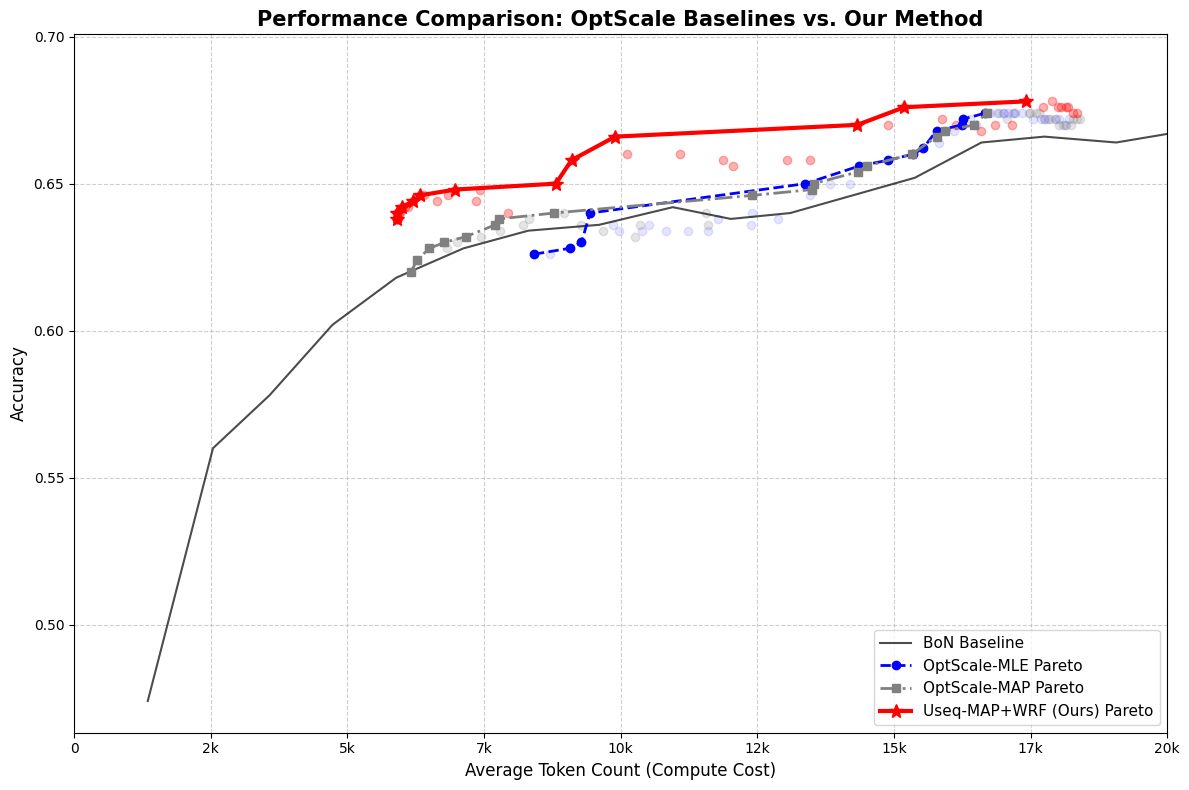

In [7]:
import math
import numpy as np
import json
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 0. 参数设置 (解锁大算力上限 N=8)
# ==========================================
target_score_panel_values = [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
percentile_panel_values = [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
max_N_panel = 16  # 调大上限，给 WRF 足够的样本进行多数投票
WINDOW_SIZE = 15

print("Target Score Panel:", target_score_panel_values)
print("Percentile Panel:", percentile_panel_values)
print(f"Max N: {max_N_panel}")

# ==========================================
# 1. 定义核心函数 (WRF投票 & 通用评测器)
# ==========================================
def get_wrf_best_answer(completions, scores, alpha=0.85): 
    if not scores: 
        return None
    
    ans_stats = {}
    for comp, score in zip(completions, scores):
        ans = get_answer(comp)
        if ans is not None and ans != "":
            if ans not in ans_stats:
                # 严格按照 WRF 逻辑，恢复平均分统计
                ans_stats[ans] = {'count': 0, 'total_score': 0.0}
            
            ans_stats[ans]['count'] += 1
            ans_stats[ans]['total_score'] += score

    if not ans_stats:
        highest_idx = scores.index(max(scores))
        return get_answer(completions[highest_idx])
        
    unique_answers = list(ans_stats.keys())
    
    if len(unique_answers) == 1:
        return unique_answers[0] 

    # 计算平均分并进行归一化
    R_dict = {ans: stats['total_score'] / stats['count'] for ans, stats in ans_stats.items()}
    F_dict = {ans: stats['count'] for ans, stats in ans_stats.items()}

    R_values = list(R_dict.values())
    F_values = list(F_dict.values())
    
    R_min, R_max = min(R_values), max(R_values)
    F_min, F_max = min(F_values), max(F_values)

    best_ans = None
    max_wrf_score = -float('inf')

    for ans in unique_answers:
        if R_max > R_min:
            norm_R = (R_dict[ans] - R_min) / (R_max - R_min)
        else:
            norm_R = 1.0  

        if F_max > F_min:
            norm_F = (F_dict[ans] - F_min) / (F_max - F_min)
        else:
            norm_F = 1.0  

        wrf_score = alpha * norm_R + (1.0 - alpha) * norm_F

        if wrf_score > max_wrf_score:
            max_wrf_score = wrf_score
            best_ans = ans

    return best_ans

from joblib import Parallel, delayed

def evaluate_method(params_list, use_wrf=False, desc=""):
    """多核并行加速版的评测器"""
    
    # 1. 扁平化网格搜索参数，共 8 * 6 = 48 组配置
    grid_configs = [(ts, p) for ts in target_score_panel_values for p in percentile_panel_values]
    
    # 2. 剥离出：单次配置的完整评测逻辑
    def eval_single_config(target_score, percentile):
        min_N_required = []
        # 计算每一题在这个阈值下需要的最小 N
        for mu, sigma in params_list:
            min_N = find_min_N_for_threshold(mu, sigma, target_score=target_score, 
                                             percentile=percentile, max_N=max_N_panel)
            if min_N < peek_number:
                min_N = peek_number
            min_N_required.append(min_N)
            
        correct = 0
        entire_token_count = 0

        # 遍历数据集
        for idx, item in enumerate(val_texts):
            N = min_N_required[idx]
            completions = val_completions[idx][0][:N]
            scores = val_scores[idx][0][:N]
            completion_tokens = val_completion_tokens[idx][0][:N]
            entire_token_count += sum(completion_tokens)

            if use_wrf:
                current_alpha = 0.85 
                final_answer = get_wrf_best_answer(completions, scores, alpha=current_alpha)
            else:
                highest_idx = scores.index(max(scores))
                while completions[highest_idx] == "":
                    scores[highest_idx] = 0 
                    if max(scores) == 0: break
                    highest_idx = scores.index(max(scores))
                final_answer = get_answer(completions[highest_idx])

            if verify_extracted_answer(val_gt_answers[idx], final_answer):
                correct += 1

        return {
            'target_score': target_score, 'percentile': percentile,
            'accuracy': correct / len(val_texts),
            'average_token_count': entire_token_count / len(val_texts)
        }

    # 3. 启动多核并行计算 (n_jobs=-1 表示火力全开，使用所有可用 CPU 核心)
    print(f"🚀 启动多核并行评测: {desc}")
    results = Parallel(n_jobs=-1)(
        delayed(eval_single_config)(ts, p) 
        for ts, p in tqdm(grid_configs, desc=f"Grid Searching")
    )
    
    return results
# ==========================================
# 2. 依次跑三个方法的评测 (三国杀)
# ==========================================
print("\n[1/3] Evaluating Baseline 1 (OptScale-MLE)...")
mle_results = evaluate_method(mle_estimated_params, use_wrf=False, desc="MLE")

print("\n[2/3] Evaluating Baseline 2 (OptScale-MAP)...")
vanilla_map_results = evaluate_method(vanilla_map_estimated_params, use_wrf=False, desc="Vanilla MAP")

print("\n[3/3] Evaluating Ours (Useq-MAP + WRF)...")
useq_map_results = evaluate_method(useq_map_estimated_params, use_wrf=True, desc="Useq-MAP+WRF")

# ---------------------------------------------------------
# 新增的诊断测试：控制变量法 (Ablation Study)
# ---------------------------------------------------------
print("\n[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...")
# 目的：看是不是 Useq-MAP 算出来的算力分配 N 有问题
useq_bon_results = evaluate_method(useq_map_estimated_params, use_wrf=False, desc="Useq-MAP + BoN")

print("\n[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...")
# 目的：看是不是 WRF 投票机制在 GSM8K 上水土不服
vanilla_wrf_results = evaluate_method(vanilla_map_estimated_params, use_wrf=True, desc="Vanilla MAP + WRF")




# (可选) 将我们的最好结果存下来
with open(f'{DATASET}_Useq_MAP_WRF_results_{max_N_panel}.json', 'w') as f:
    json.dump(useq_map_results, f)

# ==========================================
# 3. 终极数据提取与画图
# ==========================================
print("\n[INFO] 正在提取并打印帕累托最优配置...")

def get_pareto_frontier(results):
    """提取帕累托前沿点，并保留其所有配置参数"""
    # 按 Token 消耗从小到大排序
    sorted_results = sorted(results, key=lambda x: x['average_token_count'])
    pareto_front = []
    max_acc = -1
    for res in sorted_results:
        # 帕累托核心逻辑：只有当准确率严格大于之前的最大值时，才将其加入前沿
        if res['accuracy'] > max_acc:
            pareto_front.append(res)
            max_acc = res['accuracy']
    return pareto_front

def print_pareto_config(name, pareto_front):
    """精美打印配置表"""
    print(f"\n{'-'*60}")
    print(f"🌟 {name} Pareto-optimal configurations:")
    print(f"{'-'*60}")
    for res in pareto_front:
        print(f"Target Score: {res['target_score']:<5} | Percentile: {res['percentile']:<5} | "
              f"Accuracy: {res['accuracy']:.4f} | Avg Token Count: {res['average_token_count']:.2f}")

# 1. 提取三条前沿数据
mle_pareto = get_pareto_frontier(mle_results)
vanilla_map_pareto = get_pareto_frontier(vanilla_map_results)
useq_map_pareto = get_pareto_frontier(useq_map_results)

useq_bon_results = get_pareto_frontier(useq_bon_results)
vanilla_wrf_results = get_pareto_frontier(vanilla_wrf_results)


# 2. 打印到终端 (直接可以复制进论文的表格里)

print_pareto_config("OptScale-MLE", mle_pareto)
print_pareto_config("OptScale-MAP (Vanilla)", vanilla_map_pareto)
print_pareto_config("Useq-MAP+WRF (Ours)", useq_map_pareto)
print_pareto_config("只测 Useq-MAP 参数，不用 WRF (用原版最高分)", useq_bon_results)
print_pareto_config("用原版的 Vanilla MAP 参数，加上 WRF", vanilla_wrf_results)

# 3. 画图环节
plt.figure(figsize=(12, 8))

# 画原版 Best-of-N 基线 (黑线)
if 'baseline_accuracy_values' in locals() and baseline_accuracy_values:
    plt.plot(baseline_average_token_counts, baseline_accuracy_values, 'k-', label='BoN Baseline', alpha=0.7)

# 分离出 x(Token) 和 y(Accuracy) 用于画线
mle_x = [r['average_token_count'] for r in mle_pareto]
mle_y = [r['accuracy'] for r in mle_pareto]

vanilla_x = [r['average_token_count'] for r in vanilla_map_pareto]
vanilla_y = [r['accuracy'] for r in vanilla_map_pareto]

useq_x = [r['average_token_count'] for r in useq_map_pareto]
useq_y = [r['accuracy'] for r in useq_map_pareto]

# 1. 蓝线：MLE
plt.scatter([r['average_token_count'] for r in mle_results], [r['accuracy'] for r in mle_results], c='blue', alpha=0.1)
plt.plot(mle_x, mle_y, 'b--', linewidth=2, marker='o', label='OptScale-MLE Pareto')

# 2. 灰线：Vanilla MAP
plt.scatter([r['average_token_count'] for r in vanilla_map_results], [r['accuracy'] for r in vanilla_map_results], c='gray', alpha=0.2)
plt.plot(vanilla_x, vanilla_y, color='gray', linestyle='-.', linewidth=2, marker='s', label='OptScale-MAP Pareto')

# 3. 红线：Ours (Useq-MAP + WRF)
plt.scatter([r['average_token_count'] for r in useq_map_results], [r['accuracy'] for r in useq_map_results], c='red', alpha=0.3)
plt.plot(useq_x, useq_y, 'r-', linewidth=3, marker='*', markersize=10, label='Useq-MAP+WRF (Ours) Pareto')

# 格式化 X 轴，让它显示 10k, 20k 这种紧凑格式，看起来更高级
def format_func(value, tick_number):
    return f'{int(value/1000)}k' if value >= 1000 else int(value)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# 图表美化
plt.title('Performance Comparison: OptScale Baselines vs. Our Method', fontsize=15, fontweight='bold')
plt.xlabel('Average Token Count (Compute Cost)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
# 【新增这行代码】限制 X 轴范围从 0 到 100,000
plt.xlim(0, 20000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
import math
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


# =====================================================================
# 【修改】定义带权重的截断正态分布 MAP 目标函数 
# 在截断逻辑的基础上加入权重
# =====================================================================
def neg_log_posterior_weighted(params, data_array, weights, prior_mu, prior_sigma, prior_mu_std=0.1, prior_sigma_std=0.1):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
        
    # Log likelihood (Truncated Normal Logic)
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    if Z <= 0:
        return np.inf

    # 计算每个样本的未加权对数似然 (不包含 Z)
    per_sample_log_lik = norm.logpdf((data_array - mu)/sigma) - np.log(sigma)
    
    # 加权求和：让高质量样本主导拟合
    weighted_sum = np.sum(weights * per_sample_log_lik)
    
    # 归一化项惩罚
    # 这里的逻辑是：权重之和代表了“有效样本量”，用来缩放截断带来的惩罚
    effective_n = np.sum(weights) 
    if effective_n == 0: effective_n = 1e-6 # 防止全为0权重导致的问题
    
    log_likelihood = weighted_sum - effective_n * np.log(Z)
    
    # Log prior
    log_prior_mu = norm.logpdf(mu, loc=prior_mu, scale=prior_mu_std)
    log_prior_sigma = norm.logpdf(sigma, loc=prior_sigma, scale=prior_sigma_std)
    
    return -(log_likelihood + log_prior_mu + log_prior_sigma)


# 1. 算上帝视角 GT 参数 (保持原样)
original_params_compare = []
for idx, score in enumerate(val_scores):
    data = np.array(score[0][:100])
    initial_mu = np.mean(data)
    initial_sigma = np.std(data)
    result = minimize(lambda params: neg_log_likelihood(params, data), 
                     [initial_mu, initial_sigma],
                     bounds=[(None, None), (1e-6, None)], 
                     method='L-BFGS-B')
    mu_hat, sigma_hat = result.x
    original_params_compare.append((mu_hat, sigma_hat))

# 2. 准备储存三组实验数据的列表
mle_estimated_params = []          # [基线 1] OptScale-MLE 
vanilla_map_estimated_params = []  # [基线 2] OptScale-MAP (截断版)
useq_map_estimated_params = []     # [我们] Useq-MAP (带测谎仪+截断)
predictor_params = []              # 1.5B 预测先验

# 3. 完美对齐的表头打印
print("\nComparison of Estimation Methods (first 50 examples):")
header = (f"{'ID':<5} | {'Prior_μ':>10} {'Prior_σ':>10} | "
          f"{'MLE_μ':>10} {'MLE_σ':>10} | "
          f"{'Opt_MAP_μ':>12} {'Opt_MAP_σ':>12} | "
          f"{'Useq_MAP_μ':>12} {'Useq_MAP_σ':>12} | "
          f"{'GT_μ':>10} {'GT_σ':>10}")
print(header)
print("-" * len(header))

peek_number = 10
WINDOW_SIZE = 15 

for i, (score, prediction, useq) in enumerate(zip(val_scores, val_labels, val_useqs)):
    peek_data = np.array(score[0][:peek_number])
    peek_useqs = np.array(useq[0][:peek_number])
    
    # 储存先验
    prior_mu, prior_sigma = prediction
    predictor_params.append((prior_mu, prior_sigma))
    
    # ----------------------------------------------------
    # [推断 1] 计算 MLE
    initial_mu, initial_sigma = np.mean(peek_data), np.std(peek_data)
    mle_result = minimize(
        lambda params: neg_log_likelihood(params, peek_data),
        [initial_mu, initial_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    mle_mu, mle_sigma = mle_result.x
    mle_estimated_params.append((mle_mu, mle_sigma))
    
    # ----------------------------------------------------
    # [推断 2] 计算 OptScale-MAP (Vanilla MAP - 截断版)
    # 注意：这里不需要传 weights
    vanilla_map_result = minimize(
        lambda params: neg_log_posterior(
            params, peek_data, prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    opt_map_mu, opt_map_sigma = vanilla_map_result.x
    vanilla_map_estimated_params.append((opt_map_mu, opt_map_sigma))
    
    # ----------------------------------------------------
    # [推断 3] 计算 Useq-MAP (我们的方法 - 截断+加权)
    weights = []
    for u in peek_useqs:
        if u > 900: 
            weights.append(0.0)
        else: 
            weights.append(1.0 / math.exp(u / WINDOW_SIZE))
            
    useq_map_result = minimize(
        lambda params: neg_log_posterior_weighted(
            params, peek_data, weights=np.array(weights), prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    useq_map_mu, useq_map_sigma = useq_map_result.x
    useq_map_estimated_params.append((useq_map_mu, useq_map_sigma))
    
    # ----------------------------------------------------
    # 打印对比
    if i < 50:
        gt_mu, gt_sigma = original_params_compare[i]
        print(f"{i:<5} | {prior_mu:10.4f} {prior_sigma:10.4f} | "
            f"{mle_mu:10.4f} {mle_sigma:10.4f} | "
            f"{opt_map_mu:12.4f} {opt_map_sigma:12.4f} | "
            f"{useq_map_mu:12.4f} {useq_map_sigma:12.4f} | "
            f"{gt_mu:10.4f} {gt_sigma:10.4f}")

# 评估性能
analyze_estimation_performance(predictor_params, mle_estimated_params, useq_map_estimated_params, original_params_compare)


Comparison of Estimation Methods (first 50 examples):
ID    |    Prior_μ    Prior_σ |      MLE_μ      MLE_σ |    Opt_MAP_μ    Opt_MAP_σ |   Useq_MAP_μ   Useq_MAP_σ |       GT_μ       GT_σ
-------------------------------------------------------------------------------------------------------------------------------------
0     |     0.9538     0.0798 |     0.8460     0.0804 |       0.8551       0.0831 |       0.8915       0.1037 |     0.8583     0.1831
1     |     0.8792     0.0529 |    10.0221     1.2015 |       0.8981       0.5966 |       0.9235       0.1811 |    64.8574     2.6690
2     |     0.8755     0.1231 |     0.6973     0.1700 |       0.7587       0.1859 |       0.8137       0.1910 |     0.7683     0.1627
3     |     0.9809     0.0482 |    32.3877     1.0898 |       1.0910       0.0882 |       1.0469       0.0816 |   106.7850     2.8311
4     |     0.9098     0.0816 |     3.3321     0.7268 |       0.8867       0.3052 |       0.9184       0.1851 |    88.1711     3.7865
5     |

Target Score Panel: [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
Percentile Panel: [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
Max N: 32

[1/3] Evaluating Baseline 1 (OptScale-MLE)...
🚀 启动多核并行评测: MLE


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 30676.00it/s]



[2/3] Evaluating Baseline 2 (OptScale-MAP)...
🚀 启动多核并行评测: Vanilla MAP


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 28765.05it/s]



[3/3] Evaluating Ours (Useq-MAP + WRF)...
🚀 启动多核并行评测: Useq-MAP+WRF


...


[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...
🚀 启动多核并行评测: Useq-MAP + BoN


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 20551.92it/s]



[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...
🚀 启动多核并行评测: Vanilla MAP + WRF


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 13779.11it/s]



[INFO] 正在提取并打印帕累托最优配置...

------------------------------------------------------------
🌟 OptScale-MLE Pareto-optimal configurations:
------------------------------------------------------------
Target Score: 0.7   | Percentile: 0.1   | Accuracy: 0.6400 | Avg Token Count: 13184.93
Target Score: 0.75  | Percentile: 0.05  | Accuracy: 0.6420 | Avg Token Count: 15316.34
Target Score: 0.7   | Percentile: 0.01  | Accuracy: 0.6440 | Avg Token Count: 15445.90
Target Score: 0.75  | Percentile: 0.01  | Accuracy: 0.6460 | Avg Token Count: 17747.67
Target Score: 0.85  | Percentile: 0.1   | Accuracy: 0.6480 | Avg Token Count: 19065.44
Target Score: 0.8   | Percentile: 0.02  | Accuracy: 0.6500 | Avg Token Count: 19539.55
Target Score: 0.85  | Percentile: 0.035 | Accuracy: 0.6520 | Avg Token Count: 22103.27
Target Score: 0.85  | Percentile: 0.02  | Accuracy: 0.6580 | Avg Token Count: 23392.26
Target Score: 0.9   | Percentile: 0.075 | Accuracy: 0.6600 | Avg Token Count: 24840.03
Target Score: 0.925 | 

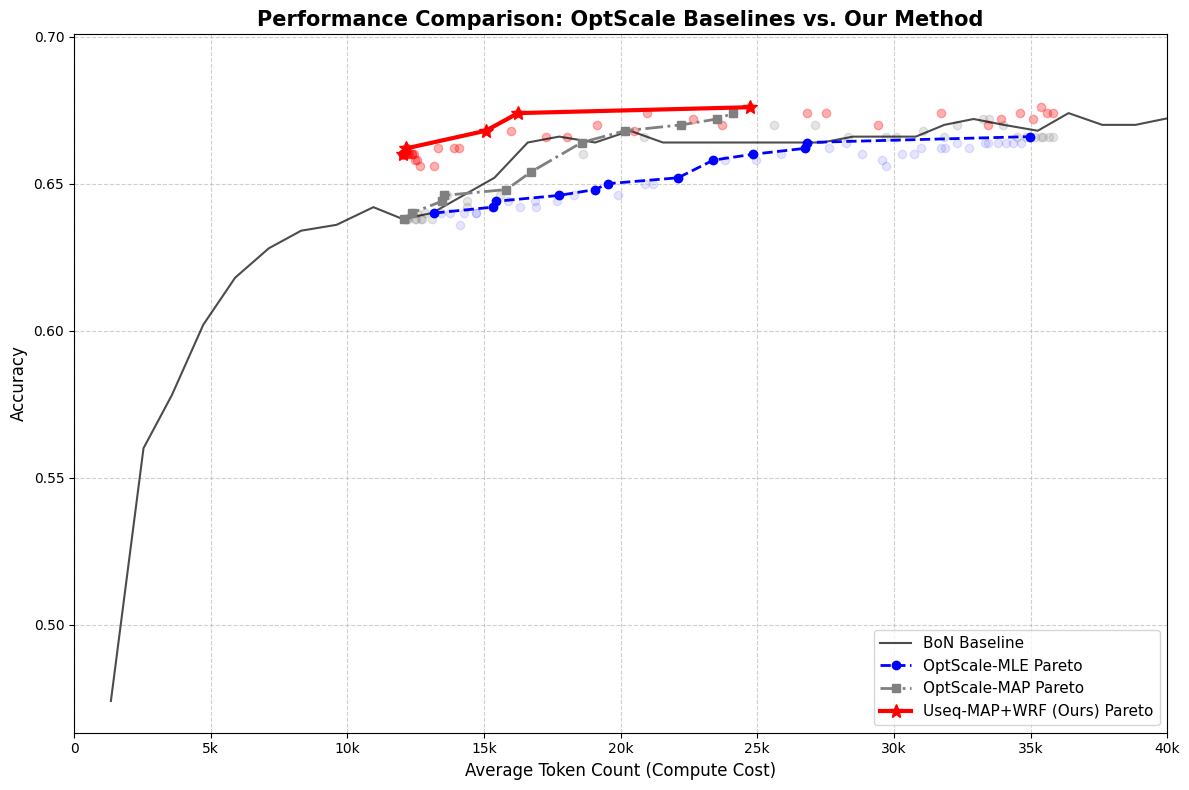

In [9]:
import math
import numpy as np
import json
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 0. 参数设置 (解锁大算力上限 N=8)
# ==========================================
target_score_panel_values = [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
percentile_panel_values = [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
max_N_panel = 32  # 调大上限，给 WRF 足够的样本进行多数投票
WINDOW_SIZE = 15

print("Target Score Panel:", target_score_panel_values)
print("Percentile Panel:", percentile_panel_values)
print(f"Max N: {max_N_panel}")

# ==========================================
# 1. 定义核心函数 (WRF投票 & 通用评测器)
# ==========================================
def get_wrf_best_answer(completions, scores, alpha=0.85): 
    if not scores: 
        return None
    
    ans_stats = {}
    for comp, score in zip(completions, scores):
        ans = get_answer(comp)
        if ans is not None and ans != "":
            if ans not in ans_stats:
                # 严格按照 WRF 逻辑，恢复平均分统计
                ans_stats[ans] = {'count': 0, 'total_score': 0.0}
            
            ans_stats[ans]['count'] += 1
            ans_stats[ans]['total_score'] += score

    if not ans_stats:
        highest_idx = scores.index(max(scores))
        return get_answer(completions[highest_idx])
        
    unique_answers = list(ans_stats.keys())
    
    if len(unique_answers) == 1:
        return unique_answers[0] 

    # 计算平均分并进行归一化
    R_dict = {ans: stats['total_score'] / stats['count'] for ans, stats in ans_stats.items()}
    F_dict = {ans: stats['count'] for ans, stats in ans_stats.items()}

    R_values = list(R_dict.values())
    F_values = list(F_dict.values())
    
    R_min, R_max = min(R_values), max(R_values)
    F_min, F_max = min(F_values), max(F_values)

    best_ans = None
    max_wrf_score = -float('inf')

    for ans in unique_answers:
        if R_max > R_min:
            norm_R = (R_dict[ans] - R_min) / (R_max - R_min)
        else:
            norm_R = 1.0  

        if F_max > F_min:
            norm_F = (F_dict[ans] - F_min) / (F_max - F_min)
        else:
            norm_F = 1.0  

        wrf_score = alpha * norm_R + (1.0 - alpha) * norm_F

        if wrf_score > max_wrf_score:
            max_wrf_score = wrf_score
            best_ans = ans

    return best_ans

from joblib import Parallel, delayed

def evaluate_method(params_list, use_wrf=False, desc=""):
    """多核并行加速版的评测器"""
    
    # 1. 扁平化网格搜索参数，共 8 * 6 = 48 组配置
    grid_configs = [(ts, p) for ts in target_score_panel_values for p in percentile_panel_values]
    
    # 2. 剥离出：单次配置的完整评测逻辑
    def eval_single_config(target_score, percentile):
        min_N_required = []
        # 计算每一题在这个阈值下需要的最小 N
        for mu, sigma in params_list:
            min_N = find_min_N_for_threshold(mu, sigma, target_score=target_score, 
                                             percentile=percentile, max_N=max_N_panel)
            if min_N < peek_number:
                min_N = peek_number
            min_N_required.append(min_N)
            
        correct = 0
        entire_token_count = 0

        # 遍历数据集
        for idx, item in enumerate(val_texts):
            N = min_N_required[idx]
            completions = val_completions[idx][0][:N]
            scores = val_scores[idx][0][:N]
            completion_tokens = val_completion_tokens[idx][0][:N]
            entire_token_count += sum(completion_tokens)

            if use_wrf:
                current_alpha = 0.85 
                final_answer = get_wrf_best_answer(completions, scores, alpha=current_alpha)
            else:
                highest_idx = scores.index(max(scores))
                while completions[highest_idx] == "":
                    scores[highest_idx] = 0 
                    if max(scores) == 0: break
                    highest_idx = scores.index(max(scores))
                final_answer = get_answer(completions[highest_idx])

            if verify_extracted_answer(val_gt_answers[idx], final_answer):
                correct += 1

        return {
            'target_score': target_score, 'percentile': percentile,
            'accuracy': correct / len(val_texts),
            'average_token_count': entire_token_count / len(val_texts)
        }

    # 3. 启动多核并行计算 (n_jobs=-1 表示火力全开，使用所有可用 CPU 核心)
    print(f"🚀 启动多核并行评测: {desc}")
    results = Parallel(n_jobs=-1)(
        delayed(eval_single_config)(ts, p) 
        for ts, p in tqdm(grid_configs, desc=f"Grid Searching")
    )
    
    return results
# ==========================================
# 2. 依次跑三个方法的评测 (三国杀)
# ==========================================
print("\n[1/3] Evaluating Baseline 1 (OptScale-MLE)...")
mle_results = evaluate_method(mle_estimated_params, use_wrf=False, desc="MLE")

print("\n[2/3] Evaluating Baseline 2 (OptScale-MAP)...")
vanilla_map_results = evaluate_method(vanilla_map_estimated_params, use_wrf=False, desc="Vanilla MAP")

print("\n[3/3] Evaluating Ours (Useq-MAP + WRF)...")
useq_map_results = evaluate_method(useq_map_estimated_params, use_wrf=True, desc="Useq-MAP+WRF")

# ---------------------------------------------------------
# 新增的诊断测试：控制变量法 (Ablation Study)
# ---------------------------------------------------------
print("\n[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...")
# 目的：看是不是 Useq-MAP 算出来的算力分配 N 有问题
useq_bon_results = evaluate_method(useq_map_estimated_params, use_wrf=False, desc="Useq-MAP + BoN")

print("\n[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...")
# 目的：看是不是 WRF 投票机制在 GSM8K 上水土不服
vanilla_wrf_results = evaluate_method(vanilla_map_estimated_params, use_wrf=True, desc="Vanilla MAP + WRF")




# (可选) 将我们的最好结果存下来
with open(f'{DATASET}_Useq_MAP_WRF_results_{max_N_panel}.json', 'w') as f:
    json.dump(useq_map_results, f)

# ==========================================
# 3. 终极数据提取与画图
# ==========================================
print("\n[INFO] 正在提取并打印帕累托最优配置...")

def get_pareto_frontier(results):
    """提取帕累托前沿点，并保留其所有配置参数"""
    # 按 Token 消耗从小到大排序
    sorted_results = sorted(results, key=lambda x: x['average_token_count'])
    pareto_front = []
    max_acc = -1
    for res in sorted_results:
        # 帕累托核心逻辑：只有当准确率严格大于之前的最大值时，才将其加入前沿
        if res['accuracy'] > max_acc:
            pareto_front.append(res)
            max_acc = res['accuracy']
    return pareto_front

def print_pareto_config(name, pareto_front):
    """精美打印配置表"""
    print(f"\n{'-'*60}")
    print(f"🌟 {name} Pareto-optimal configurations:")
    print(f"{'-'*60}")
    for res in pareto_front:
        print(f"Target Score: {res['target_score']:<5} | Percentile: {res['percentile']:<5} | "
              f"Accuracy: {res['accuracy']:.4f} | Avg Token Count: {res['average_token_count']:.2f}")

# 1. 提取三条前沿数据
mle_pareto = get_pareto_frontier(mle_results)
vanilla_map_pareto = get_pareto_frontier(vanilla_map_results)
useq_map_pareto = get_pareto_frontier(useq_map_results)

useq_bon_results = get_pareto_frontier(useq_bon_results)
vanilla_wrf_results = get_pareto_frontier(vanilla_wrf_results)


# 2. 打印到终端 (直接可以复制进论文的表格里)

print_pareto_config("OptScale-MLE", mle_pareto)
print_pareto_config("OptScale-MAP (Vanilla)", vanilla_map_pareto)
print_pareto_config("Useq-MAP+WRF (Ours)", useq_map_pareto)
print_pareto_config("只测 Useq-MAP 参数，不用 WRF (用原版最高分)", useq_bon_results)
print_pareto_config("用原版的 Vanilla MAP 参数，加上 WRF", vanilla_wrf_results)

# 3. 画图环节
plt.figure(figsize=(12, 8))

# 画原版 Best-of-N 基线 (黑线)
if 'baseline_accuracy_values' in locals() and baseline_accuracy_values:
    plt.plot(baseline_average_token_counts, baseline_accuracy_values, 'k-', label='BoN Baseline', alpha=0.7)

# 分离出 x(Token) 和 y(Accuracy) 用于画线
mle_x = [r['average_token_count'] for r in mle_pareto]
mle_y = [r['accuracy'] for r in mle_pareto]

vanilla_x = [r['average_token_count'] for r in vanilla_map_pareto]
vanilla_y = [r['accuracy'] for r in vanilla_map_pareto]

useq_x = [r['average_token_count'] for r in useq_map_pareto]
useq_y = [r['accuracy'] for r in useq_map_pareto]

# 1. 蓝线：MLE
plt.scatter([r['average_token_count'] for r in mle_results], [r['accuracy'] for r in mle_results], c='blue', alpha=0.1)
plt.plot(mle_x, mle_y, 'b--', linewidth=2, marker='o', label='OptScale-MLE Pareto')

# 2. 灰线：Vanilla MAP
plt.scatter([r['average_token_count'] for r in vanilla_map_results], [r['accuracy'] for r in vanilla_map_results], c='gray', alpha=0.2)
plt.plot(vanilla_x, vanilla_y, color='gray', linestyle='-.', linewidth=2, marker='s', label='OptScale-MAP Pareto')

# 3. 红线：Ours (Useq-MAP + WRF)
plt.scatter([r['average_token_count'] for r in useq_map_results], [r['accuracy'] for r in useq_map_results], c='red', alpha=0.3)
plt.plot(useq_x, useq_y, 'r-', linewidth=3, marker='*', markersize=10, label='Useq-MAP+WRF (Ours) Pareto')

# 格式化 X 轴，让它显示 10k, 20k 这种紧凑格式，看起来更高级
def format_func(value, tick_number):
    return f'{int(value/1000)}k' if value >= 1000 else int(value)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# 图表美化
plt.title('Performance Comparison: OptScale Baselines vs. Our Method', fontsize=15, fontweight='bold')
plt.xlabel('Average Token Count (Compute Cost)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
# 【新增这行代码】限制 X 轴范围从 0 到 100,000
plt.xlim(0, 40000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
import math
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


# =====================================================================
# 【修改】定义带权重的截断正态分布 MAP 目标函数 
# 在截断逻辑的基础上加入权重
# =====================================================================
def neg_log_posterior_weighted(params, data_array, weights, prior_mu, prior_sigma, prior_mu_std=0.1, prior_sigma_std=0.1):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
        
    # Log likelihood (Truncated Normal Logic)
    a = (0 - mu) / sigma
    b = (1 - mu) / sigma
    Z = norm.cdf(b) - norm.cdf(a)
    if Z <= 0:
        return np.inf

    # 计算每个样本的未加权对数似然 (不包含 Z)
    per_sample_log_lik = norm.logpdf((data_array - mu)/sigma) - np.log(sigma)
    
    # 加权求和：让高质量样本主导拟合
    weighted_sum = np.sum(weights * per_sample_log_lik)
    
    # 归一化项惩罚
    # 这里的逻辑是：权重之和代表了“有效样本量”，用来缩放截断带来的惩罚
    effective_n = np.sum(weights) 
    if effective_n == 0: effective_n = 1e-6 # 防止全为0权重导致的问题
    
    log_likelihood = weighted_sum - effective_n * np.log(Z)
    
    # Log prior
    log_prior_mu = norm.logpdf(mu, loc=prior_mu, scale=prior_mu_std)
    log_prior_sigma = norm.logpdf(sigma, loc=prior_sigma, scale=prior_sigma_std)
    
    return -(log_likelihood + log_prior_mu + log_prior_sigma)


# 1. 算上帝视角 GT 参数 (保持原样)
original_params_compare = []
for idx, score in enumerate(val_scores):
    data = np.array(score[0][:100])
    initial_mu = np.mean(data)
    initial_sigma = np.std(data)
    result = minimize(lambda params: neg_log_likelihood(params, data), 
                     [initial_mu, initial_sigma],
                     bounds=[(None, None), (1e-6, None)], 
                     method='L-BFGS-B')
    mu_hat, sigma_hat = result.x
    original_params_compare.append((mu_hat, sigma_hat))

# 2. 准备储存三组实验数据的列表
mle_estimated_params = []          # [基线 1] OptScale-MLE 
vanilla_map_estimated_params = []  # [基线 2] OptScale-MAP (截断版)
useq_map_estimated_params = []     # [我们] Useq-MAP (带测谎仪+截断)
predictor_params = []              # 1.5B 预测先验

# 3. 完美对齐的表头打印
print("\nComparison of Estimation Methods (first 50 examples):")
header = (f"{'ID':<5} | {'Prior_μ':>10} {'Prior_σ':>10} | "
          f"{'MLE_μ':>10} {'MLE_σ':>10} | "
          f"{'Opt_MAP_μ':>12} {'Opt_MAP_σ':>12} | "
          f"{'Useq_MAP_μ':>12} {'Useq_MAP_σ':>12} | "
          f"{'GT_μ':>10} {'GT_σ':>10}")
print(header)
print("-" * len(header))

peek_number = 20
WINDOW_SIZE = 15 

for i, (score, prediction, useq) in enumerate(zip(val_scores, val_labels, val_useqs)):
    peek_data = np.array(score[0][:peek_number])
    peek_useqs = np.array(useq[0][:peek_number])
    
    # 储存先验
    prior_mu, prior_sigma = prediction
    predictor_params.append((prior_mu, prior_sigma))
    
    # ----------------------------------------------------
    # [推断 1] 计算 MLE
    initial_mu, initial_sigma = np.mean(peek_data), np.std(peek_data)
    mle_result = minimize(
        lambda params: neg_log_likelihood(params, peek_data),
        [initial_mu, initial_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    mle_mu, mle_sigma = mle_result.x
    mle_estimated_params.append((mle_mu, mle_sigma))
    
    # ----------------------------------------------------
    # [推断 2] 计算 OptScale-MAP (Vanilla MAP - 截断版)
    # 注意：这里不需要传 weights
    vanilla_map_result = minimize(
        lambda params: neg_log_posterior(
            params, peek_data, prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    opt_map_mu, opt_map_sigma = vanilla_map_result.x
    vanilla_map_estimated_params.append((opt_map_mu, opt_map_sigma))
    
    # ----------------------------------------------------
    # [推断 3] 计算 Useq-MAP (我们的方法 - 截断+加权)
    weights = []
    for u in peek_useqs:
        if u > 900: 
            weights.append(0.0)
        else: 
            weights.append(1.0 / math.exp(u / WINDOW_SIZE))
            
    useq_map_result = minimize(
        lambda params: neg_log_posterior_weighted(
            params, peek_data, weights=np.array(weights), prior_mu=prior_mu, prior_sigma=prior_sigma
        ),
        [prior_mu, prior_sigma], bounds=[(None, None), (1e-6, None)], method='L-BFGS-B'
    )
    useq_map_mu, useq_map_sigma = useq_map_result.x
    useq_map_estimated_params.append((useq_map_mu, useq_map_sigma))
    
    # ----------------------------------------------------
    # 打印对比
    if i < 50:
        gt_mu, gt_sigma = original_params_compare[i]
        print(f"{i:<5} | {prior_mu:10.4f} {prior_sigma:10.4f} | "
            f"{mle_mu:10.4f} {mle_sigma:10.4f} | "
            f"{opt_map_mu:12.4f} {opt_map_sigma:12.4f} | "
            f"{useq_map_mu:12.4f} {useq_map_sigma:12.4f} | "
            f"{gt_mu:10.4f} {gt_sigma:10.4f}")

# 评估性能
analyze_estimation_performance(predictor_params, mle_estimated_params, useq_map_estimated_params, original_params_compare)


Comparison of Estimation Methods (first 50 examples):
ID    |    Prior_μ    Prior_σ |      MLE_μ      MLE_σ |    Opt_MAP_μ    Opt_MAP_σ |   Useq_MAP_μ   Useq_MAP_σ |       GT_μ       GT_σ
-------------------------------------------------------------------------------------------------------------------------------------
0     |     0.9538     0.0798 |     0.8210     0.1316 |       0.8408       0.1373 |       0.8780       0.1432 |     0.8583     0.1831
1     |     0.8792     0.0529 |    79.9580     3.2340 |       0.8730       0.9342 |       0.8990       0.3301 |    64.8574     2.6690
2     |     0.8755     0.1231 |     0.7257     0.1907 |       0.7620       0.1980 |       0.8103       0.2004 |     0.7683     0.1627
3     |     0.9809     0.0482 |   119.3176     3.5352 |       0.9490       0.5899 |       0.9958       0.2129 |   106.7850     2.8311
4     |     0.9098     0.0816 |    65.5318     3.4850 |       0.9635       0.2288 |       0.8991       0.2985 |    88.1711     3.7865
5     |

Target Score Panel: [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
Percentile Panel: [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
Max N: 64

[1/3] Evaluating Baseline 1 (OptScale-MLE)...
🚀 启动多核并行评测: MLE


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 21866.69it/s]



[2/3] Evaluating Baseline 2 (OptScale-MAP)...
🚀 启动多核并行评测: Vanilla MAP


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 36144.81it/s]



[3/3] Evaluating Ours (Useq-MAP + WRF)...
🚀 启动多核并行评测: Useq-MAP+WRF


...


[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...
🚀 启动多核并行评测: Useq-MAP + BoN


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 25276.41it/s]



[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...
🚀 启动多核并行评测: Vanilla MAP + WRF


Grid Searching: 100%|██████████| 48/48 [00:00<00:00, 29395.03it/s]



[INFO] 正在提取并打印帕累托最优配置...

------------------------------------------------------------
🌟 OptScale-MLE Pareto-optimal configurations:
------------------------------------------------------------
Target Score: 0.7   | Percentile: 0.1   | Accuracy: 0.6640 | Avg Token Count: 24080.75
Target Score: 0.75  | Percentile: 0.035 | Accuracy: 0.6680 | Avg Token Count: 25445.53
Target Score: 0.75  | Percentile: 0.02  | Accuracy: 0.6700 | Avg Token Count: 26081.12
Target Score: 0.75  | Percentile: 0.01  | Accuracy: 0.6720 | Avg Token Count: 27125.16
Target Score: 0.85  | Percentile: 0.035 | Accuracy: 0.6740 | Avg Token Count: 33058.70
Target Score: 0.925 | Percentile: 0.01  | Accuracy: 0.6760 | Avg Token Count: 50021.55
Target Score: 0.95  | Percentile: 0.02  | Accuracy: 0.6780 | Avg Token Count: 54144.77
Target Score: 0.95  | Percentile: 0.01  | Accuracy: 0.6840 | Avg Token Count: 56364.64
Target Score: 0.975 | Percentile: 0.02  | Accuracy: 0.6880 | Avg Token Count: 61978.07

---------------------

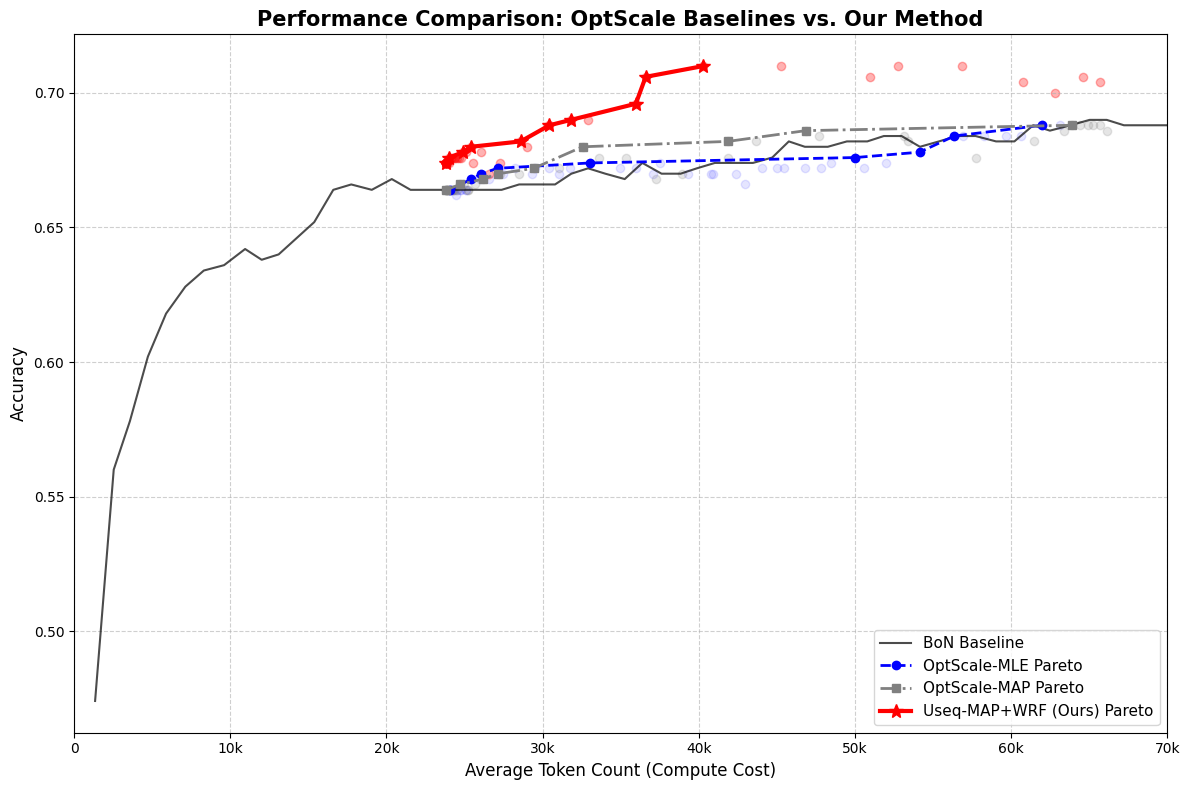

In [11]:
import math
import numpy as np
import json
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 0. 参数设置 (解锁大算力上限 N=8)
# ==========================================
target_score_panel_values = [0.7, 0.75, 0.8, 0.85, 0.9, 0.925, 0.95, 0.975]
percentile_panel_values = [0.01, 0.02, 0.035, 0.05, 0.075, 0.1]
max_N_panel = 64  # 调大上限，给 WRF 足够的样本进行多数投票
WINDOW_SIZE = 15

print("Target Score Panel:", target_score_panel_values)
print("Percentile Panel:", percentile_panel_values)
print(f"Max N: {max_N_panel}")

# ==========================================
# 1. 定义核心函数 (WRF投票 & 通用评测器)
# ==========================================
def get_wrf_best_answer(completions, scores, alpha=0.85): 
    if not scores: 
        return None
    
    ans_stats = {}
    for comp, score in zip(completions, scores):
        ans = get_answer(comp)
        if ans is not None and ans != "":
            if ans not in ans_stats:
                # 严格按照 WRF 逻辑，恢复平均分统计
                ans_stats[ans] = {'count': 0, 'total_score': 0.0}
            
            ans_stats[ans]['count'] += 1
            ans_stats[ans]['total_score'] += score

    if not ans_stats:
        highest_idx = scores.index(max(scores))
        return get_answer(completions[highest_idx])
        
    unique_answers = list(ans_stats.keys())
    
    if len(unique_answers) == 1:
        return unique_answers[0] 

    # 计算平均分并进行归一化
    R_dict = {ans: stats['total_score'] / stats['count'] for ans, stats in ans_stats.items()}
    F_dict = {ans: stats['count'] for ans, stats in ans_stats.items()}

    R_values = list(R_dict.values())
    F_values = list(F_dict.values())
    
    R_min, R_max = min(R_values), max(R_values)
    F_min, F_max = min(F_values), max(F_values)

    best_ans = None
    max_wrf_score = -float('inf')

    for ans in unique_answers:
        if R_max > R_min:
            norm_R = (R_dict[ans] - R_min) / (R_max - R_min)
        else:
            norm_R = 1.0  

        if F_max > F_min:
            norm_F = (F_dict[ans] - F_min) / (F_max - F_min)
        else:
            norm_F = 1.0  

        wrf_score = alpha * norm_R + (1.0 - alpha) * norm_F

        if wrf_score > max_wrf_score:
            max_wrf_score = wrf_score
            best_ans = ans

    return best_ans

from joblib import Parallel, delayed

def evaluate_method(params_list, use_wrf=False, desc=""):
    """多核并行加速版的评测器"""
    
    # 1. 扁平化网格搜索参数，共 8 * 6 = 48 组配置
    grid_configs = [(ts, p) for ts in target_score_panel_values for p in percentile_panel_values]
    
    # 2. 剥离出：单次配置的完整评测逻辑
    def eval_single_config(target_score, percentile):
        min_N_required = []
        # 计算每一题在这个阈值下需要的最小 N
        for mu, sigma in params_list:
            min_N = find_min_N_for_threshold(mu, sigma, target_score=target_score, 
                                             percentile=percentile, max_N=max_N_panel)
            if min_N < peek_number:
                min_N = peek_number
            min_N_required.append(min_N)
            
        correct = 0
        entire_token_count = 0

        # 遍历数据集
        for idx, item in enumerate(val_texts):
            N = min_N_required[idx]
            completions = val_completions[idx][0][:N]
            scores = val_scores[idx][0][:N]
            completion_tokens = val_completion_tokens[idx][0][:N]
            entire_token_count += sum(completion_tokens)

            if use_wrf:
                current_alpha = 0.75 
                final_answer = get_wrf_best_answer(completions, scores, alpha=current_alpha)
            else:
                highest_idx = scores.index(max(scores))
                while completions[highest_idx] == "":
                    scores[highest_idx] = 0 
                    if max(scores) == 0: break
                    highest_idx = scores.index(max(scores))
                final_answer = get_answer(completions[highest_idx])

            if verify_extracted_answer(val_gt_answers[idx], final_answer):
                correct += 1

        return {
            'target_score': target_score, 'percentile': percentile,
            'accuracy': correct / len(val_texts),
            'average_token_count': entire_token_count / len(val_texts)
        }

    # 3. 启动多核并行计算 (n_jobs=-1 表示火力全开，使用所有可用 CPU 核心)
    print(f"🚀 启动多核并行评测: {desc}")
    results = Parallel(n_jobs=-1)(
        delayed(eval_single_config)(ts, p) 
        for ts, p in tqdm(grid_configs, desc=f"Grid Searching")
    )
    
    return results
# ==========================================
# 2. 依次跑三个方法的评测 (三国杀)
# ==========================================
print("\n[1/3] Evaluating Baseline 1 (OptScale-MLE)...")
mle_results = evaluate_method(mle_estimated_params, use_wrf=False, desc="MLE")

print("\n[2/3] Evaluating Baseline 2 (OptScale-MAP)...")
vanilla_map_results = evaluate_method(vanilla_map_estimated_params, use_wrf=False, desc="Vanilla MAP")

print("\n[3/3] Evaluating Ours (Useq-MAP + WRF)...")
useq_map_results = evaluate_method(useq_map_estimated_params, use_wrf=True, desc="Useq-MAP+WRF")

# ---------------------------------------------------------
# 新增的诊断测试：控制变量法 (Ablation Study)
# ---------------------------------------------------------
print("\n[诊断 1] 只测 Useq-MAP 参数，不用 WRF (用原版最高分)...")
# 目的：看是不是 Useq-MAP 算出来的算力分配 N 有问题
useq_bon_results = evaluate_method(useq_map_estimated_params, use_wrf=False, desc="Useq-MAP + BoN")

print("\n[诊断 2] 用原版的 Vanilla MAP 参数，加上 WRF...")
# 目的：看是不是 WRF 投票机制在 GSM8K 上水土不服
vanilla_wrf_results = evaluate_method(vanilla_map_estimated_params, use_wrf=True, desc="Vanilla MAP + WRF")




# (可选) 将我们的最好结果存下来
with open(f'{DATASET}_Useq_MAP_WRF_results_{max_N_panel}.json', 'w') as f:
    json.dump(useq_map_results, f)

# ==========================================
# 3. 终极数据提取与画图
# ==========================================
print("\n[INFO] 正在提取并打印帕累托最优配置...")

def get_pareto_frontier(results):
    """提取帕累托前沿点，并保留其所有配置参数"""
    # 按 Token 消耗从小到大排序
    sorted_results = sorted(results, key=lambda x: x['average_token_count'])
    pareto_front = []
    max_acc = -1
    for res in sorted_results:
        # 帕累托核心逻辑：只有当准确率严格大于之前的最大值时，才将其加入前沿
        if res['accuracy'] > max_acc:
            pareto_front.append(res)
            max_acc = res['accuracy']
    return pareto_front

def print_pareto_config(name, pareto_front):
    """精美打印配置表"""
    print(f"\n{'-'*60}")
    print(f"🌟 {name} Pareto-optimal configurations:")
    print(f"{'-'*60}")
    for res in pareto_front:
        print(f"Target Score: {res['target_score']:<5} | Percentile: {res['percentile']:<5} | "
              f"Accuracy: {res['accuracy']:.4f} | Avg Token Count: {res['average_token_count']:.2f}")

# 1. 提取三条前沿数据
mle_pareto = get_pareto_frontier(mle_results)
vanilla_map_pareto = get_pareto_frontier(vanilla_map_results)
useq_map_pareto = get_pareto_frontier(useq_map_results)

useq_bon_results = get_pareto_frontier(useq_bon_results)
vanilla_wrf_results = get_pareto_frontier(vanilla_wrf_results)


# 2. 打印到终端 (直接可以复制进论文的表格里)

print_pareto_config("OptScale-MLE", mle_pareto)
print_pareto_config("OptScale-MAP (Vanilla)", vanilla_map_pareto)
print_pareto_config("Useq-MAP+WRF (Ours)", useq_map_pareto)
print_pareto_config("只测 Useq-MAP 参数，不用 WRF (用原版最高分)", useq_bon_results)
print_pareto_config("用原版的 Vanilla MAP 参数，加上 WRF", vanilla_wrf_results)

# 3. 画图环节
plt.figure(figsize=(12, 8))

# 画原版 Best-of-N 基线 (黑线)
if 'baseline_accuracy_values' in locals() and baseline_accuracy_values:
    plt.plot(baseline_average_token_counts, baseline_accuracy_values, 'k-', label='BoN Baseline', alpha=0.7)

# 分离出 x(Token) 和 y(Accuracy) 用于画线
mle_x = [r['average_token_count'] for r in mle_pareto]
mle_y = [r['accuracy'] for r in mle_pareto]

vanilla_x = [r['average_token_count'] for r in vanilla_map_pareto]
vanilla_y = [r['accuracy'] for r in vanilla_map_pareto]

useq_x = [r['average_token_count'] for r in useq_map_pareto]
useq_y = [r['accuracy'] for r in useq_map_pareto]

# 1. 蓝线：MLE
plt.scatter([r['average_token_count'] for r in mle_results], [r['accuracy'] for r in mle_results], c='blue', alpha=0.1)
plt.plot(mle_x, mle_y, 'b--', linewidth=2, marker='o', label='OptScale-MLE Pareto')

# 2. 灰线：Vanilla MAP
plt.scatter([r['average_token_count'] for r in vanilla_map_results], [r['accuracy'] for r in vanilla_map_results], c='gray', alpha=0.2)
plt.plot(vanilla_x, vanilla_y, color='gray', linestyle='-.', linewidth=2, marker='s', label='OptScale-MAP Pareto')

# 3. 红线：Ours (Useq-MAP + WRF)
plt.scatter([r['average_token_count'] for r in useq_map_results], [r['accuracy'] for r in useq_map_results], c='red', alpha=0.3)
plt.plot(useq_x, useq_y, 'r-', linewidth=3, marker='*', markersize=10, label='Useq-MAP+WRF (Ours) Pareto')

# 格式化 X 轴，让它显示 10k, 20k 这种紧凑格式，看起来更高级
def format_func(value, tick_number):
    return f'{int(value/1000)}k' if value >= 1000 else int(value)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# 图表美化
plt.title('Performance Comparison: OptScale Baselines vs. Our Method', fontsize=15, fontweight='bold')
plt.xlabel('Average Token Count (Compute Cost)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
# 【新增这行代码】限制 X 轴范围从 0 到 100,000
plt.xlim(0, 70000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()